### Noise Robustness in Speech Feature Analysis

This script demonstrates the impact of white noise on speech representations by comparing clean and noisy audio across multiple feature domains. It visualizes how additive noise distorts acoustic features and affects automatic speech recognition.

Key Libraries Used:

    librosa: MFCC and Mel spectrogram computation

    sounddevice: Audio recording and playback

    scipy.signal: Linear spectrogram calculation

    plotly: Feature visualization

    whisper: Speech transcription

    numpy: Signal processing and noise generation

Code Logic and Flow

The pipeline:

    Records clean speech

    Generates noisy version with white noise

    Computes and compares four feature representations

    Transcribes clean speech to text

    Visualizes noise impact across domains

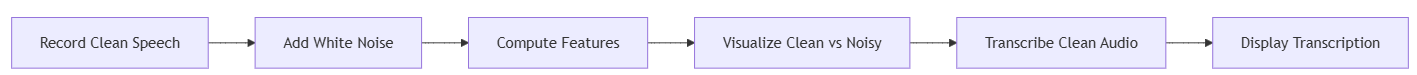

Step-by-Step Code Breakdown

1. Audio Recording & Noise Injection

    Captures 3 seconds of 16kHz speech

    Adds Gaussian white noise at 10% amplitude

    Clips to prevent digital distortion (±1.0)

2. Feature Computation

    Waveform: Raw amplitude vs time

    Linear Spectrogram:

        256-sample STFT windows with 50% overlap

        Log-scaled amplitude (dB)

    Mel Spectrogram:

        128-band Mel filterbank

        Perceptual frequency scaling

    MFCCs:

        13 cepstral coefficients

        Compact spectral representation

3. Comparative Visualization

    4×2 grid showing clean/noisy pairs:

        Waveforms (time domain)

        Linear spectrograms (frequency vs time)

        Mel spectrograms (perceptual scaling)

        MFCCs (compressed features)

    Highlights noise artifacts in each domain

4. Speech Transcription

    Uses Whisper-base for English transcription

    Processes only clean audio to show ideal case

    Demonstrates ASR performance without noise

5. Feature Sensitivity Analysis

    Waveform: Noise adds high-frequency fluctuations

    Spectrograms: Noise fills spectral valleys

    MFCCs: Higher coefficients more noise-sensitive

    Mel: Perceptual scaling partially masks noise

Connecting to Lecture Concepts

This implementation demonstrates:

    Noise Vulnerability: Additive noise distorts all feature domains

    Feature Robustness: MFCCs show relative noise resilience

    Perceptual Masking: Mel scale's noise-suppression effect

    Spectral Smearing: Noise fills formant valleys in spectrograms

    ASR Sensitivity: Clean transcription vs. noisy feature degradation

    Signal-to-Noise Ratio: 10% noise ≈ 20dB SNR (typical office)

    Front-End Processing: Feature extraction as ASR's first stage

    Noise Types: White noise as worst-case scenario (flat spectrum)

    Visual Diagnostics: Identifying noise artifacts in features

    Robustness Techniques: Basis for noise-reduction algorithms

    Real-World Relevance: Simulates challenging acoustic environments

    Research Applications: Benchmarking feature robustness

In [2]:
import numpy as np
import librosa
import scipy.signal as signal
import sounddevice as sd
import soundfile as sf
import whisper
import tempfile
import os
import plotly.graph_objects as go
import plotly.subplots as sp
from plotly.offline import plot

# Parameters
sample_rate = 16000  # Hz
duration = 3  # seconds
noise_scale = 0.1  # Noise amplitude is 10% of audio amplitude

# Function to record audio
def record_audio():
    print(f"Recording for {duration} seconds...")
    audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
    sd.wait()
    audio = audio.flatten()
    return audio

# Function to play audio
def play_audio(audio, sample_rate):
    print("Playing back the recorded audio...")
    sd.play(audio, samplerate=sample_rate)
    sd.wait()

# Function to add synthetic white noise
def add_white_noise(audio, noise_scale):
    noise = np.random.normal(0, noise_scale * np.max(np.abs(audio)), len(audio))
    noisy_audio = audio + noise
    noisy_audio = np.clip(noisy_audio, -1.0, 1.0)
    return noisy_audio

# Function to compute MFCCs
def compute_mfcc(audio, sample_rate):
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
    return mfcc

# Function to compute Mel spectrogram
def compute_mel_spectrogram(audio, sample_rate):
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

# Function to compute linear spectrogram
def compute_linear_spectrogram(audio, sample_rate):
    frequencies, times, Sxx = signal.spectrogram(audio, fs=sample_rate, nperseg=256, noverlap=128)
    Sxx_db = 10 * np.log10(Sxx + 1e-10)  # Add small epsilon to avoid log(0)
    return frequencies, times, Sxx_db

# Function to create mel frequency scale for plotting
def hz_to_mel(hz):
    """Convert Hz to mel scale"""
    return 2595 * np.log10(1 + hz / 700)

def mel_to_hz(mel):
    """Convert mel scale to Hz"""
    return 700 * (10**(mel / 2595) - 1)

def create_mel_scale(n_mels=128, fmin=0, fmax=8000):
    """Create mel frequency scale"""
    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)
    mel_points = np.linspace(mel_min, mel_max, n_mels)
    hz_points = mel_to_hz(mel_points)
    return hz_points

# Function to plot features using plotly
def plot_features(clean_audio, noisy_audio, sample_rate):
    """Create interactive plots using plotly"""
    
    # Create time axis
    time = np.linspace(0, len(clean_audio) / sample_rate, num=len(clean_audio))
    
    # Compute all features
    print("Computing spectrograms...")
    clean_freq, clean_times, clean_spec = compute_linear_spectrogram(clean_audio, sample_rate)
    noisy_freq, noisy_times, noisy_spec = compute_linear_spectrogram(noisy_audio, sample_rate)
    
    print("Computing mel spectrograms...")
    clean_mel = compute_mel_spectrogram(clean_audio, sample_rate)
    noisy_mel = compute_mel_spectrogram(noisy_audio, sample_rate)
    
    print("Computing MFCCs...")
    clean_mfcc = compute_mfcc(clean_audio, sample_rate)
    noisy_mfcc = compute_mfcc(noisy_audio, sample_rate)
    
    # Create mel frequency scale for y-axis
    mel_frequencies = create_mel_scale(n_mels=128, fmin=0, fmax=8000)
    
    # Create time axis for spectrograms (librosa uses different time resolution)
    mel_times = np.linspace(0, len(clean_audio) / sample_rate, clean_mel.shape[1])
    mfcc_times = np.linspace(0, len(clean_audio) / sample_rate, clean_mfcc.shape[1])
    
    # Create subplots
    fig = sp.make_subplots(
        rows=4, cols=2,
        subplot_titles=(
            'Clean Waveform', 'Noisy Waveform',
            'Clean Linear Spectrogram', 'Noisy Linear Spectrogram', 
            'Clean Mel Spectrogram', 'Noisy Mel Spectrogram',
            'Clean MFCCs', 'Noisy MFCCs'
        ),
        specs=[[{"secondary_y": False}, {"secondary_y": False}],
               [{"secondary_y": False}, {"secondary_y": False}],
               [{"secondary_y": False}, {"secondary_y": False}],
               [{"secondary_y": False}, {"secondary_y": False}]],
        vertical_spacing=0.08,
        horizontal_spacing=0.05
    )
    
    # 1. Waveforms
    fig.add_trace(
        go.Scatter(x=time, y=clean_audio, mode='lines', name='Clean Audio', 
                  line=dict(color='blue', width=1)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=time, y=noisy_audio, mode='lines', name='Noisy Audio',
                  line=dict(color='red', width=1)),
        row=1, col=2
    )
    
    # 2. Linear Spectrograms
    fig.add_trace(
        go.Heatmap(
            z=clean_spec,
            x=clean_times,
            y=clean_freq,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(x=0.47, len=0.2, y=0.75),
            name='Clean Spec'
        ),
        row=2, col=1
    )
    fig.add_trace(
        go.Heatmap(
            z=noisy_spec,
            x=noisy_times,
            y=noisy_freq,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(x=0.98, len=0.2, y=0.75),
            name='Noisy Spec'
        ),
        row=2, col=2
    )
    
    # 3. Mel Spectrograms
    fig.add_trace(
        go.Heatmap(
            z=clean_mel,
            x=mel_times,
            y=mel_frequencies,
            colorscale='Plasma',
            showscale=True,
            colorbar=dict(x=0.47, len=0.2, y=0.47),
            name='Clean Mel'
        ),
        row=3, col=1
    )
    fig.add_trace(
        go.Heatmap(
            z=noisy_mel,
            x=mel_times,
            y=mel_frequencies,
            colorscale='Plasma',
            showscale=True,
            colorbar=dict(x=0.98, len=0.2, y=0.47),
            name='Noisy Mel'
        ),
        row=3, col=2
    )
    
    # 4. MFCCs
    mfcc_coeffs = np.arange(1, clean_mfcc.shape[0] + 1)
    fig.add_trace(
        go.Heatmap(
            z=clean_mfcc,
            x=mfcc_times,
            y=mfcc_coeffs,
            colorscale='RdBu',
            showscale=True,
            colorbar=dict(x=0.47, len=0.2, y=0.19),
            name='Clean MFCC'
        ),
        row=4, col=1
    )
    fig.add_trace(
        go.Heatmap(
            z=noisy_mfcc,
            x=mfcc_times,
            y=mfcc_coeffs,
            colorscale='RdBu',
            showscale=True,
            colorbar=dict(x=0.98, len=0.2, y=0.19),
            name='Noisy MFCC'
        ),
        row=4, col=2
    )
    
    # Update layout
    fig.update_layout(
        height=1200,
        width=1400,
        title_text="Audio Feature Analysis: Clean vs Noisy",
        title_x=0.5,
        showlegend=False,
        font=dict(size=12)
    )
    
    # Update x-axis labels
    for i in range(1, 5):
        for j in range(1, 3):
            fig.update_xaxes(title_text="Time (s)", row=i, col=j)
    
    # Update y-axis labels
    fig.update_yaxes(title_text="Amplitude", row=1, col=1)
    fig.update_yaxes(title_text="Amplitude", row=1, col=2)
    fig.update_yaxes(title_text="Frequency (Hz)", row=2, col=1)
    fig.update_yaxes(title_text="Frequency (Hz)", row=2, col=2)
    fig.update_yaxes(title_text="Frequency (Hz)", row=3, col=1)
    fig.update_yaxes(title_text="Frequency (Hz)", row=3, col=2)
    fig.update_yaxes(title_text="MFCC Coefficients", row=4, col=1)
    fig.update_yaxes(title_text="MFCC Coefficients", row=4, col=2)
    
    # Save as HTML file
    plot(fig, filename='audio_features_comparison.html', auto_open=True)
    print("Interactive plot saved as: audio_features_comparison.html")
    
    # Also save as static image
    try:
        fig.write_image("audio_features_comparison.png", width=1400, height=1200, scale=2)
        print("Static plot saved as: audio_features_comparison.png")
    except Exception as e:
        print(f"Note: Could not save static PNG (install kaleido for PNG export): {e}")
    
    # Display basic statistics
    print(f"\nFeature Analysis Summary:")
    print(f"- Audio duration: {len(clean_audio) / sample_rate:.2f} seconds")
    print(f"- Clean audio RMS: {np.sqrt(np.mean(clean_audio**2)):.4f}")
    print(f"- Noisy audio RMS: {np.sqrt(np.mean(noisy_audio**2)):.4f}")
    
    # Calculate SNR
    noise = noisy_audio - clean_audio
    snr_db = 10 * np.log10(np.var(clean_audio) / (np.var(noise) + 1e-10))
    print(f"- Estimated SNR: {snr_db:.2f} dB")
    
    # Feature differences
    spec_diff = np.mean(np.abs(clean_spec - noisy_spec))
    mel_diff = np.mean(np.abs(clean_mel - noisy_mel))
    mfcc_diff = np.mean(np.abs(clean_mfcc - noisy_mfcc))
    
    print(f"- Spectrogram difference: {spec_diff:.4f}")
    print(f"- Mel spectrogram difference: {mel_diff:.4f}")
    print(f"- MFCC difference: {mfcc_diff:.4f}")
    
    return fig

# Function to transcribe audio using Whisper
def transcribe_audio(audio, sample_rate, language="en"):
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmpfile:
        sf.write(tmpfile.name, audio, sample_rate)
        tmpfile_path = tmpfile.name

    print("Loading Whisper model...")
    model = whisper.load_model("base")
    print("Transcribing audio...")
    result = model.transcribe(tmpfile_path, language=language)
    transcript = result["text"]

    os.remove(tmpfile_path)
    return transcript

# Main function
def main():
    print("Starting audio analysis with Plotly visualization...")
    
    clean_audio = record_audio()
    play_audio(clean_audio, sample_rate)
    noisy_audio = add_white_noise(clean_audio, noise_scale)
    
    # Create interactive plots
    fig = plot_features(clean_audio, noisy_audio, sample_rate)
    
    # Transcribe audio
    transcript = transcribe_audio(clean_audio, sample_rate, language="en")  # Change to "hi" for Hindi
    print(f"\nTranscribed Text: '{transcript}'")
    
    return fig

if __name__ == "__main__":
    main()

Starting audio analysis with Plotly visualization...
Recording for 3 seconds...
Playing back the recorded audio...
Computing spectrograms...
Computing mel spectrograms...
Computing MFCCs...
Interactive plot saved as: audio_features_comparison.html
Note: Could not save static PNG (install kaleido for PNG export): 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome



Feature Analysis Summary:
- Audio duration: 3.00 seconds
- Clean audio RMS: 0.2301
- Noisy audio RMS: 0.2490
- Estimated SNR: 7.30 dB
- Spectrogram difference: 28.2853
- Mel spectrogram difference: 24.2847
- MFCC difference: 35.5645
Loading Whisper model...
Transcribing audio...

Transcribed Text: ' Hello dear, how is everything?'
